# Business Understanding

## Project Domain

## Problem Statements

## Goals

## Solution Statements

# Data Understanding

## Import data dari kaggle

In [44]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1) (1).json


{'kaggle (1) (1).json': b'{"username":"felixdtengker","key":"9116a0e570548dda4ccb3a3a309bfce3"}'}

In [45]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [46]:
!kaggle datasets download -d bhavyadhingra00020/india-rental-house-price

Dataset URL: https://www.kaggle.com/datasets/bhavyadhingra00020/india-rental-house-price
License(s): apache-2.0
india-rental-house-price.zip: Skipping, found more recently modified local copy (use --force to force download)


In [47]:
!mkdir india-rental-house-price
!unzip india-rental-house-price -d india-rental-house-price
!ls india-rental-house-price

mkdir: cannot create directory ‘india-rental-house-price’: File exists
Archive:  india-rental-house-price.zip
replace india-rental-house-price/Indian_housing_Delhi_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: Indian_housing_Delhi_data.csv	Indian_housing_Pune_data.csv
Indian_housing_Mumbai_data.csv


## Import Library yang dibutuhkan

In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

## Exploratory Data Analysis

In [49]:
df = pd.read_csv('/content/india-rental-house-price/Indian_housing_Mumbai_data.csv')

In [50]:
df = pd.read_csv('/content/india-rental-house-price/Indian_housing_Delhi_data.csv')

In [51]:
df = pd.read_csv('/content/india-rental-house-price/Indian_housing_Pune_data.csv')

In [52]:
df.head(10)

,house_type,house_size,location,city,latitude,longitude,price,currency,numBathrooms,numBalconies,isNegotiable,priceSqFt,verificationDate,description,SecurityDeposit,Status
0,2 BHK Apartment,906 sq ft,Lohegaon,Pune,18.605820,73.912407,12000,INR,2.0,NaN,NaN,NaN,Posted 3 years ago,A spacious 2 bhk multistorey apartment is avai...,No Deposit,Unfurnished
1,1 BHK Apartment,650 sq ft,Anand Nagar,Pune,18.474377,73.820549,11000,INR,1.0,NaN,NaN,NaN,Posted 2 years ago,It has a built-up area of 650 sqft and is avai...,No Deposit,Semi-Furnished
2,1 RK Studio Apartment,350 sq ft,Wagholi,Pune,18.580336,73.980507,4500,INR,1.0,NaN,NaN,NaN,Posted 2 years ago,This spacious 1 rk independent house is availa...,No Deposit,Unfurnished
3,3 BHK Apartment,"1,500 sq ft",Sangamvadi,Pune,18.541786,73.882454,35000,INR,2.0,NaN,NaN,NaN,Posted 3 years ago,"Furnishings include 1 tv, 1 refrigerator, 1 so...",No Deposit,Furnished
4,5 BHK Independent House,"5,000 sq ft",Wadgaon Sheri,Pune,18.560164,73.924927,110000,INR,5.0,NaN,NaN,NaN,Posted 3 years ago,Itâs a 5 bhk independent house situated in W...,No Deposit,Unfurnished
5,2 BHK Apartment,975 sq ft,Tathawade,Pune,18.640373,73.736862,15500,INR,2.0,NaN,NaN,NaN,Posted 3 years ago,Itâs a 2 bhk multistorey apartment situated ...,No Deposit,Semi-Furnished
6,1 BHK Independent House,540 sq ft,Hinjewadi,Pune,18.579365,73.735886,24000,INR,1.0,NaN,NaN,NaN,Posted a month ago,A spacious 1 bhk independent house is availabl...,No Deposit,Unfurnished
7,2 BHK Apartment,800 sq ft,Viman Nagar,Pune,18.572426,73.907677,40000,INR,2.0,NaN,NaN,NaN,Posted a month ago,Well designed 2 bhk multistorey apartment is a...,No Deposit,Semi-Furnished
8,2 BHK Apartment,"1,050 sq ft",Undri,Pune,18.446608,73.905540,16000,INR,2.0,NaN,NaN,NaN,Posted a month ago,A 2 bhk property is available for rental in Ga...,No Deposit,Unfurnished
9,2 BHK Apartment,"1,050 sq ft",Pimple Nilakh,Pune,18.568186,73.790688,38000,INR,2.0,NaN,NaN,NaN,Posted 16 days ago,A spacious 2 bhk multistorey apartment is avai...,No Deposit,Semi-Furnished


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3910 entries, 0 to 3909
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   house_type        3910 non-null   object 
 1   house_size        3910 non-null   object 
 2   location          3910 non-null   object 
 3   city              3910 non-null   object 
 4   latitude          3910 non-null   float64
 5   longitude         3910 non-null   float64
 6   price             3910 non-null   int64  
 7   currency          3910 non-null   object 
 8   numBathrooms      3893 non-null   float64
 9   numBalconies      1821 non-null   float64
 10  isNegotiable      526 non-null    object 
 11  priceSqFt         0 non-null      float64
 12  verificationDate  3910 non-null   object 
 13  description       3442 non-null   object 
 14  SecurityDeposit   3910 non-null   object 
 15  Status            3910 non-null   object 
dtypes: float64(5), int64(1), object(10)
memory

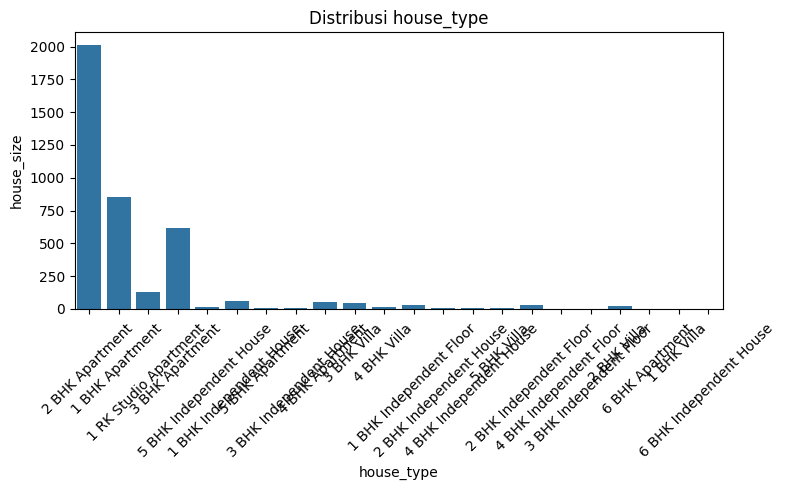

In [54]:
plt.figure(figsize=(8, 5))
sns.countplot(x='house_type', data=df)
plt.title('Distribusi house_type')
plt.xlabel('house_type')
plt.ylabel('house_size')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

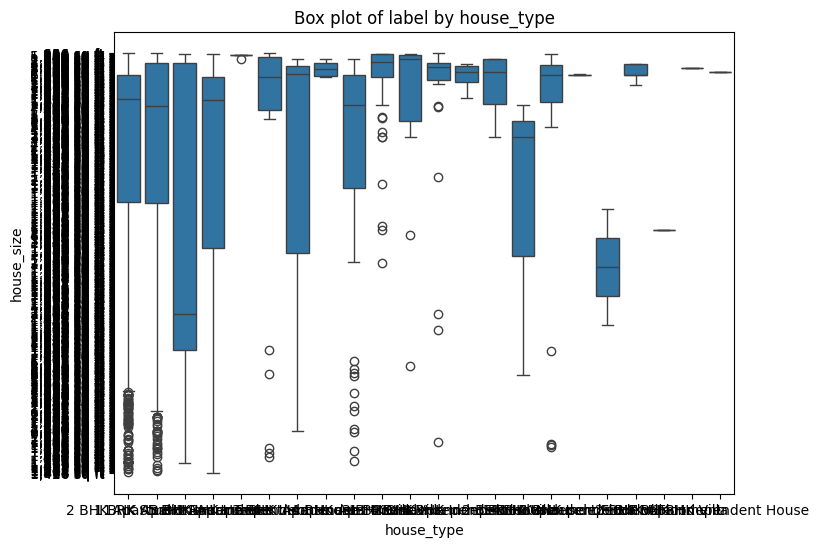

In [55]:
plt.figure(figsize=(8,6))
sns.boxplot(x='house_type', y='house_size', data=df)
plt.title('Box plot of label by house_type')
plt.xlabel('house_type')
plt.ylabel('house_size')
plt.show()

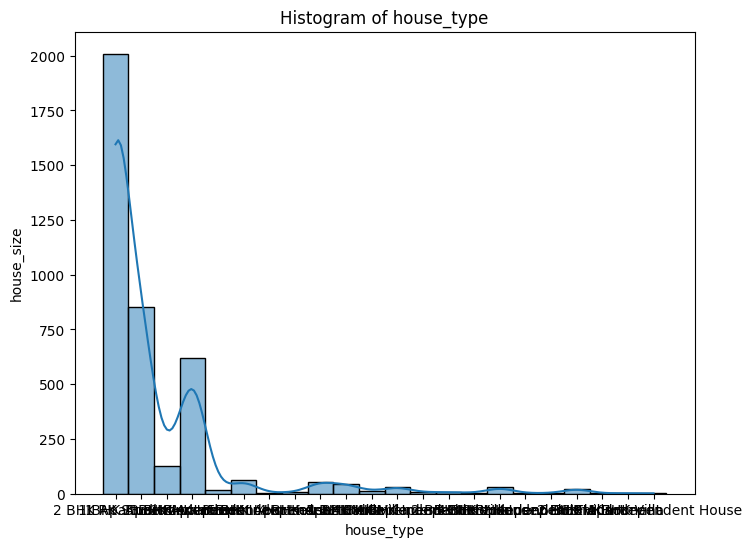

In [56]:
plt.figure(figsize=(8, 6))
sns.histplot(df['house_type'], kde=True)
plt.title('Histogram of house_type')
plt.xlabel('house_type')
plt.ylabel('house_size')
plt.show()

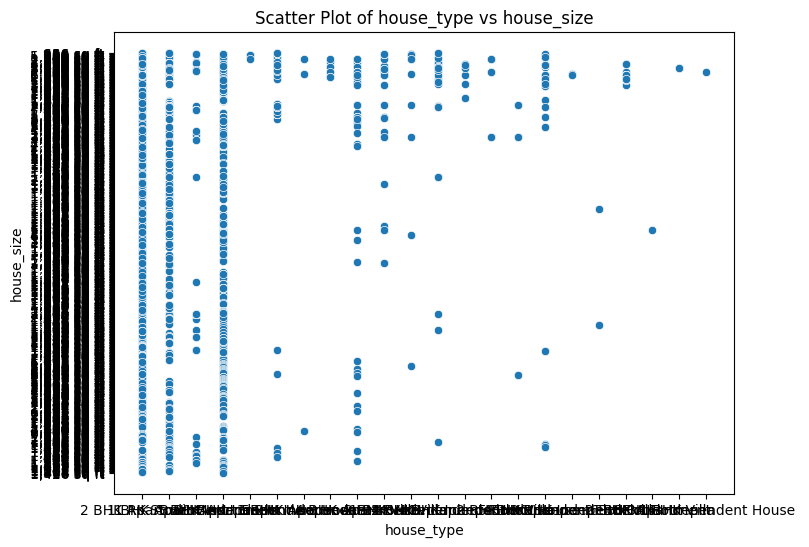

In [57]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='house_type', y='house_size', data=df)
plt.title('Scatter Plot of house_type vs house_size')
plt.xlabel('house_type')
plt.ylabel('house_size')
plt.show()

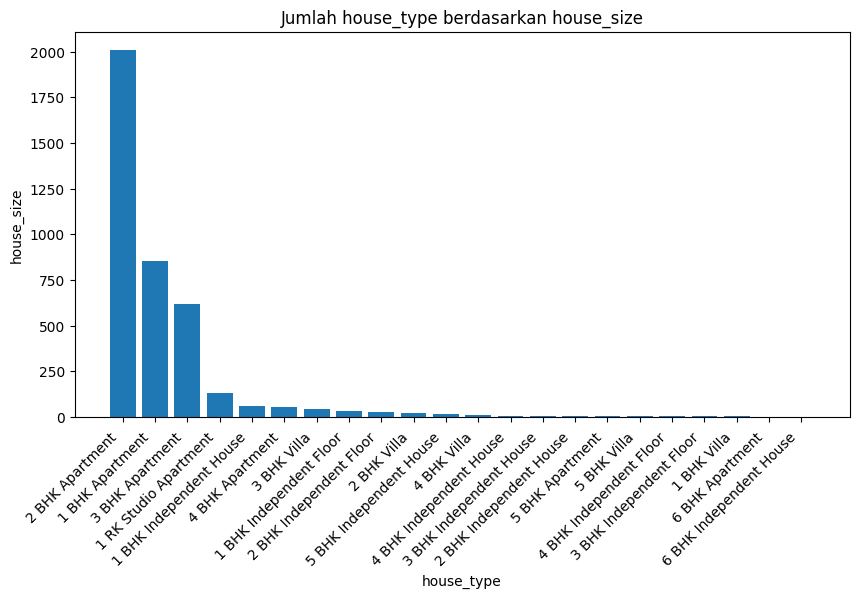

In [58]:
education_counts = df['house_type'].value_counts()
plt.figure(figsize=(10,5))
plt.bar(education_counts.index, education_counts.values)
plt.xlabel('house_type')
plt.ylabel('house_size')
plt.title('Jumlah house_type berdasarkan house_size')
plt.xticks(rotation=45, ha='right')
plt.show()

# Data Preparation

In [59]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [60]:
df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

In [61]:
target_col = 'city'
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

In [62]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/usr/local/lib/python3.11/dist-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [64]:
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (3128, 15)
X_test shape: (782, 15)
y_train shape: (3128,)
y_test shape: (782,)


In [65]:
le = LabelEncoder()

df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col]) # Use the initialized le

# Modeling

In [66]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(len(le.classes_), activation="softmax")
])

In [67]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [68]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,483 (48.76 KB)

 Trainable params: 12,483 (48.76 KB)

 Non-trainable params: 0 (0.00 B)

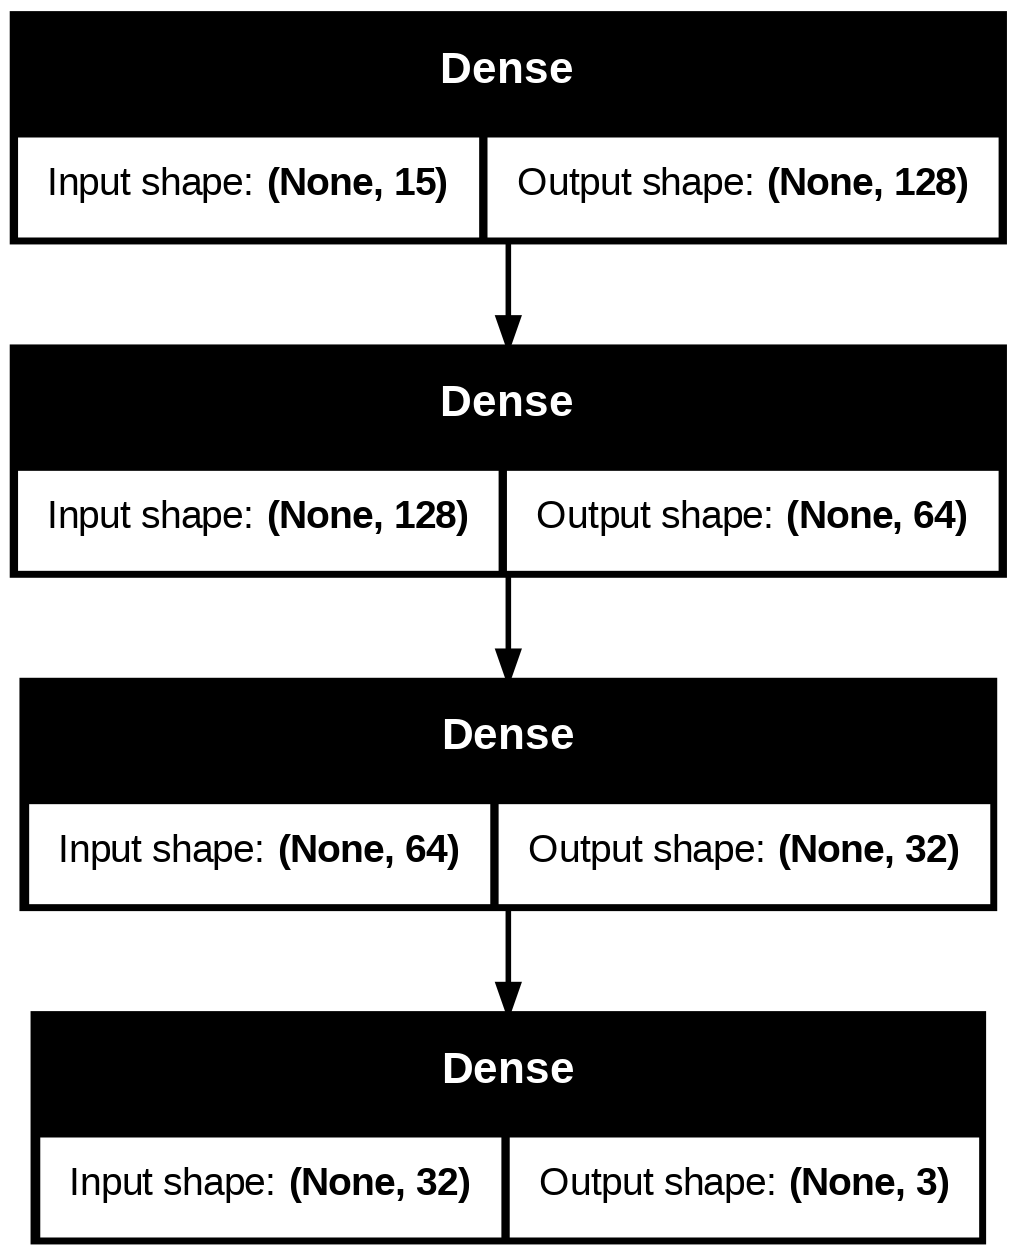

In [69]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [70]:
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_data=(X_test, y_test))

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 1.0000 - loss: nan - val_accuracy: 1.0000 - val_loss: nan
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: nan - val_accuracy: 1.0000 - val_loss: nan
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: nan - val_accuracy: 1.0000 - val_loss: nan
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: nan - val_accuracy: 1.0000 - val_loss: nan
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: nan - val_accuracy: 1.0000 - val_loss: nan
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: nan - val_accuracy: 1.0000 - val_loss: nan
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: nan - val_accuracy: 1.0000 - val_loss: nan
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: nan - val_accuracy: 1.0000 - val_loss: nan
Epoch 9/50
196/196 ━━━━━

# Evaluation

In [71]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: nan 
Akurasi Model: 1.0000
Loss Model: nan


In [72]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.2%}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy: 100.00%


In [73]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

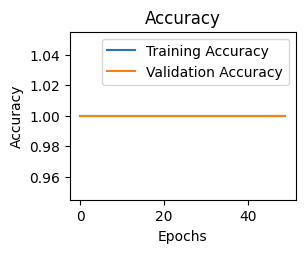

In [74]:
plt.subplot(2, 2, 4)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

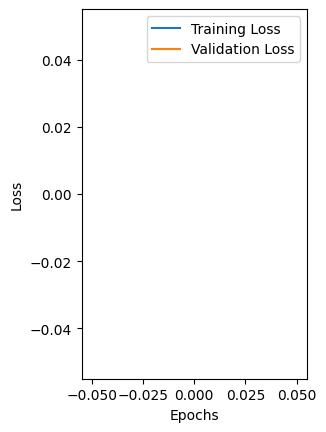

In [75]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


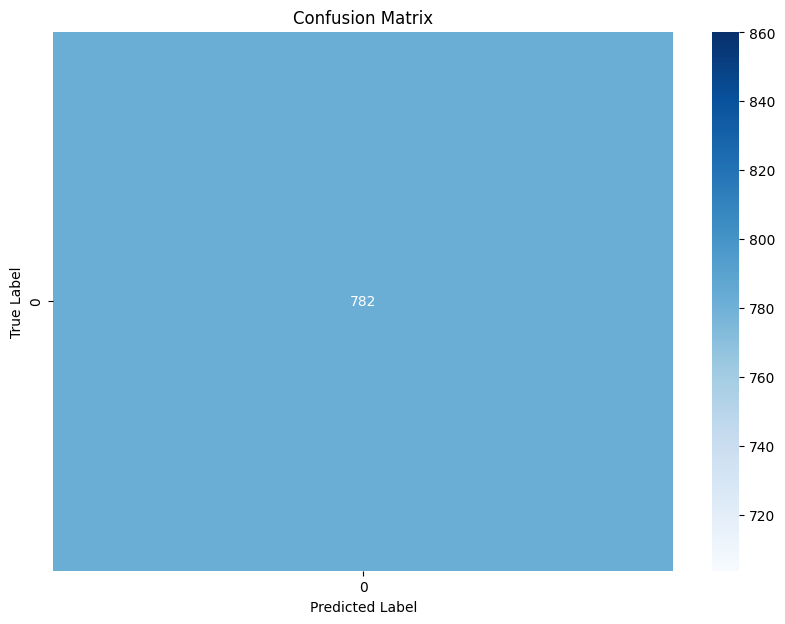

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       782

    accuracy                           1.00       782
   macro avg       1.00      1.00      1.00       782
weighted avg       1.00      1.00      1.00       782



In [76]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [77]:
sample_input = np.array([[78, 42 ,42, 20.13, 81.60, 7.62, 262.71, 0, 0, 0, 0, 0, 0, 0, 0]])  # Add missing columns with placeholder values (e.g., 0)
sample_input_df = pd.DataFrame(sample_input)

In [78]:
sample_input_scaled = scaler.transform(sample_input_df)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [79]:
predicted_class = np.argmax(model.predict(sample_input_scaled))
predicted_crop = le.inverse_transform([predicted_class])

print(f"city: {predicted_crop[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
city: Furnished


## Save Model

In [80]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('india-rental-house-price.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpxk4mj_et'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 15), dtype=tf.float32, name='keras_tensor_7')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133392347454864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133392347458704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133392347452368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133392347456400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133392347455824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133392347457168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133392347451984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133392347455056: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [81]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']